## Variational Fourier Regression

In [1]:
import jax
from jax import config
from jax import Array
import jax.numpy as jnp
config.update("jax_enable_x64", True)  # do this at the very top

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams["figure.figsize"] = (5, 3)
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]  # matches LaTeX default

import mplcyberpunk
plt.style.use("cyberpunk")

from vgd.model import FourierPredictor
from vgd.distribution import FourierParticles, NormalDiag, SignedMixtureLike
from vgd.kernel import RBFKernel, KernelParams
from vgd.loss import DeterministicRiskLoss, squared_loss_and_grad, logistic_loss_and_grad, ISFDeterministicRiskLoss
from vgd.methods import vgd, vgd_weight, mfld, vgd_random
from vgd.util import plot_1d_predictive_output, plot_isf_results
from vgd.methods.isf import isf


In [3]:
# -----------------------
# Synthetic data makers
# -----------------------
def make_regression_data(n=256, key=jax.random.PRNGKey(0)):
    kx, kn = jax.random.split(key)
    X = jax.random.uniform(kx, (n, 1), minval=-3.0, maxval=3.0)
    f_true = jnp.sin(2.0 * X[:, 0]) + 0.5 * jnp.cos(1.3 * X[:, 0])
    y = f_true + 0.15 * jax.random.normal(kn, (n,))
    return {"x": X, "y": y}, f_true  # f_true for diagnostics

def make_classification_data(n=512, key=jax.random.PRNGKey(1)):
    kx, kn = jax.random.split(key)
    X = jax.random.uniform(kx, (n, 2), minval=-2.5, maxval=2.5)
    logits = 1.2 * jnp.sin(2.0 * X[:, 0]) + 0.8 * X[:, 1]
    logits = logits + 0.5 * jax.random.normal(kn, (n,))
    probs = jax.nn.sigmoid(logits)
    y = jnp.where(probs > 0.5, 1.0, 0.0)
    return {"x": X, "y": y.astype(jnp.float32)}, logits


# -----------------------
# Fourier particle init
# -----------------------
def init_fourier_particles(
    n_particles: int,
    d: int,
    key: Array,
    w_scale: float = 1.0,          # freq std
    phase_uniform: bool = True,
    alpha_scale: float = 0.1       # weight std (smaller is usually stabler)
) -> SignedMixtureLike:
    k1, k2, k3 = jax.random.split(key, 3)
    omega = jax.random.normal(k1, (n_particles, d)) * w_scale         # (n,d)
    if phase_uniform: 
        b = jax.random.uniform(k2, (n_particles, 1), minval=0.0, maxval=2.0 * jnp.pi) 
    else: 
        b = jnp.zeros((n_particles, 1))
    particles = jnp.concatenate([omega, b], axis=1)                   # (n, d+1)
    alpha = jax.random.normal(k3, (n_particles,)) * alpha_scale       # (n,)
    return SignedMixtureLike(particles=particles, alpha=alpha)


# -----------------------
# Simple metrics
# -----------------------
def mse(y, yhat):
    r = yhat - y
    return float(jnp.mean(r * r))

def accuracy(y, logits):
    preds = (jax.nn.sigmoid(logits) >= 0.5).astype(y.dtype)
    return float(jnp.mean((preds == y).astype(jnp.float32)))



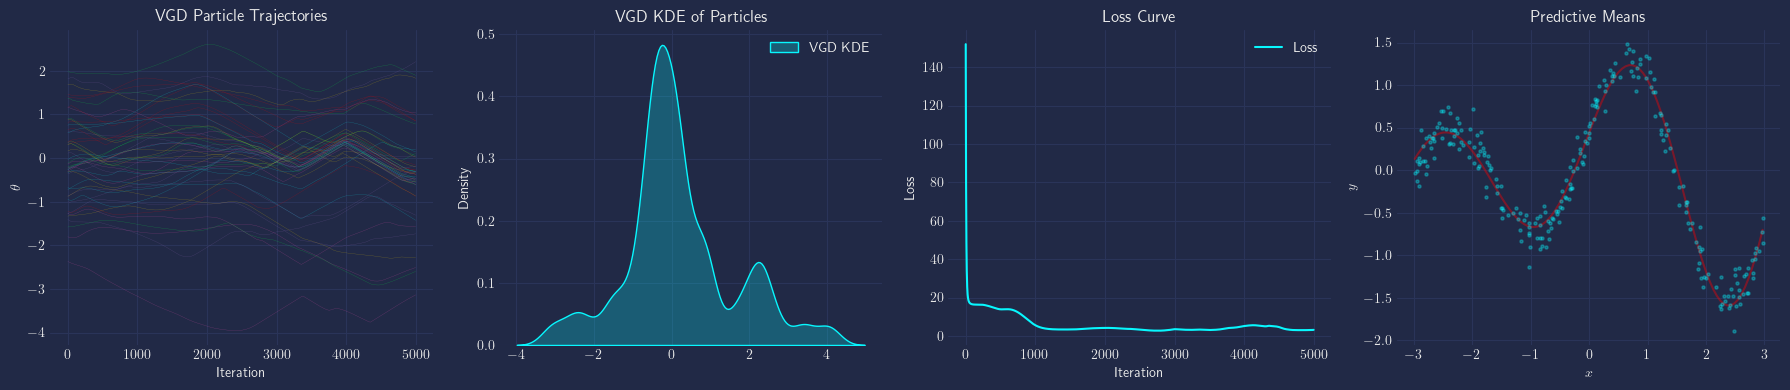

In [4]:
key = jax.random.PRNGKey(42)
data, f_true = make_regression_data(n=256, key=key)
N, d = data["x"].shape

# Init Fourier mixture
Q0 = init_fourier_particles(n_particles=48, d=d, key=key, w_scale=1.0, phase_uniform=True)

# Predictor + Loss
prior = NormalDiag(sd=1.0)
predictor = FourierPredictor(prior_plus=prior, prior_minus=prior, data = data, x_key="x", y_key="y")
loss = ISFDeterministicRiskLoss(loss_and_grad=squared_loss_and_grad)

# Kernel & params (adjust KernelParams(...) if your signature differs)
kparams = KernelParams(lengthscale=jnp.asarray(1.), amplitude=jnp.asarray(1.0)) 
kernel = RBFKernel()

# Pre-train diagnostics
f0 = predictor.predict(Q0)

# Run VGD
out = isf(
    model=predictor,
    loss=loss,
    kernel=kernel,
    kparams=kparams,
    eps_theta=1e-2,
    eps_alpha = 1e-4,
    lambda_skl = 1.,
    Q0=Q0,
    steps=5000,
    ema_alpha=1.0,
    use_median_lengthscale=True,
    return_metrics=True,
)
Qhat, metrics = out if isinstance(out, tuple) else (out, None)

Qfinal, history = out
plot_1d_predictive_output(Qfinal, history, predictor)
plt.show()

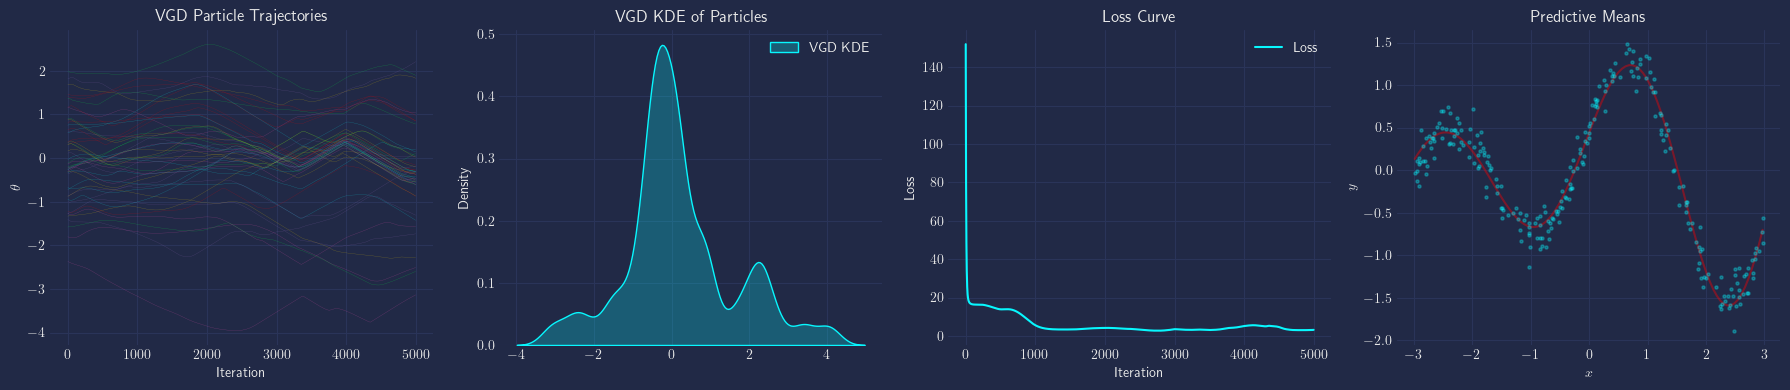

In [4]:
Qfinal, history = out
plot_1d_predictive_output(Qfinal, history, predictor)
plt.show()

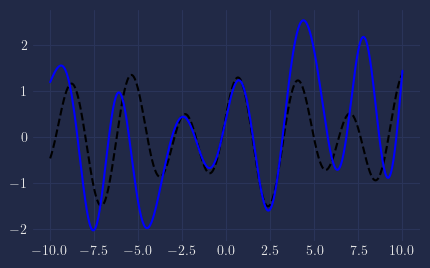

In [5]:
xgrid = jnp.linspace(-10, 10, 512).reshape(-1, 1)

ygrid = jnp.sin(2.0 * xgrid[:, 0]) + 0.5 * jnp.cos(1.3 * xgrid[:, 0])

plt.plot(xgrid, ygrid, 'k--', label='True function')

preds = predictor.predict_on_x(Qfinal, xgrid)
plt.plot(xgrid, preds, 'b', label='VG-D output')

In [6]:



def make_classification_data(n=512, key=jax.random.PRNGKey(1)):
    kx, kn = jax.random.split(key)
    X = jax.random.uniform(kx, (n, 2), minval=-2.5, maxval=2.5)
    logits = 1.2 * jnp.sin(2.0 * X[:, 0]) + 0.8 * X[:, 1]
    logits = logits + 0.5 * jax.random.normal(kn, (n,))
    probs = jax.nn.sigmoid(logits)
    y = jnp.where(probs > 0.5, 1.0, 0.0)
    return {"x": X, "y": y.astype(jnp.float32)}, logits

key = jax.random.PRNGKey(42)
data, logits = make_classification_data(n=256, key=key)
N, d = data["x"].shape

# Init Fourier mixture
Q0 = init_fourier_particles(n_particles=48, d=d, key=key, w_scale=1.0, phase_uniform=True)

# Predictor + Loss
prior = NormalDiag(sd=1.0)
predictor = FourierPredictor(prior_plus=prior, prior_minus=prior, data = data, x_key="x", y_key="y")
loss = ISFDeterministicRiskLoss(loss_and_grad=logistic_loss_and_grad)

# Kernel & params (adjust KernelParams(...) if your signature differs)
kparams = KernelParams(lengthscale=jnp.asarray(1.), amplitude=jnp.asarray(1.0)) 
kernel = RBFKernel()

# Pre-train diagnostics
f0 = predictor.predict(Q0)

# Run VGD
out = isf(
    model=predictor,
    loss=loss,
    kernel=kernel,
    kparams=kparams,
    eps_theta=1e-2,
    eps_alpha = 1e-4,
    lambda_skl = 1.,
    Q0=Q0,
    steps=5000,
    ema_alpha=1.0,
    use_median_lengthscale=True,
    return_metrics=True,
)
Qhat, metrics = out if isinstance(out, tuple) else (out, None)

# Post-train diagnostics
fhat = predictor.predict(Qhat)
print("MSE after:", mse(data["y"], fhat))

# Optional: show a couple of metric keys if present
if metrics:
    keys = list(metrics.keys())
    show = keys[:3]
    for k in show:
        try:
            print(f"metric[{k}][-1] =", float(np.array(metrics[k])[-1]))
        except Exception:
            pass


MSE after: 6.16179746525132
metric[loss][-1] = 83.39447561830862


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

def plot_isf_results(
    predictor,
    data,
    Q0,
    Qhat,
    metrics=None,
    grid_lim=2.5,
    grid_n=200,
    title_prefix="ISF"
):
    def _to_np(x):
        return np.asarray(x)

    def _grid_2d(lim=2.5, n=200):
        xs = np.linspace(-lim, lim, n)
        ys = np.linspace(-lim, lim, n)
        XX, YY = np.meshgrid(xs, ys)
        XY = np.stack([XX.ravel(), YY.ravel()], axis=1)  # (n*n, 2)
        return XX, YY, XY

    def _predict_probs(predictor, Q, XY):
        logits = _to_np(predictor.predict_on_x(Q, XY))   # (M,)
        return 1.0 / (1.0 + np.exp(-logits))

    X = _to_np(data["x"])
    y = _to_np(data["y"]).astype(int)

    XX, YY, XY = _grid_2d(lim=grid_lim, n=grid_n)

    P0 = _predict_probs(predictor, Q0, XY).reshape(XX.shape)
    Ph = _predict_probs(predictor, Qhat, XY).reshape(XX.shape)
    dP = Ph - P0


    # One figure, 2x3 grid
    fig = plt.figure(figsize=(14, 8))
    gs = gridspec.GridSpec(2, 3, figure=fig, height_ratios=[1, 1])

    # --- Axes ---
    ax_init  = fig.add_subplot(gs[0, 0])
    ax_final = fig.add_subplot(gs[0, 1])
    ax_diff  = fig.add_subplot(gs[0, 2])
    ax_loss  = fig.add_subplot(gs[1, 0])
    ax_norms = fig.add_subplot(gs[1, 1])
    ax_hist  = fig.add_subplot(gs[1, 2])

    # Common plotting helper for surfaces
    def _plot_surface(ax, Z, title, draw_points=True, levels=25, vmin=0.0, vmax=1.0, show_cb=True):
        im = ax.contourf(XX, YY, Z, levels=levels, vmin=vmin, vmax=vmax, alpha=0.85)
        cs = ax.contour(XX, YY, Z, levels=[0.5], colors="k", linewidths=1.2)
        ax.clabel(cs, inline=True, fontsize=8, fmt="0.5")
        if draw_points:
            ax.scatter(X[y == 0, 0], X[y == 0, 1], s=12, c="C0", label="class 0", alpha=0.8, edgecolors="none")
            ax.scatter(X[y == 1, 0], X[y == 1, 1], s=12, c="C1", label="class 1", alpha=0.8, edgecolors="none")
            ax.legend(loc="upper right", frameon=True, fontsize=8)
        ax.set_title(title)
        ax.set_xlabel("x1"); ax.set_ylabel("x2")
        ax.set_xlim(-grid_lim, grid_lim); ax.set_ylim(-grid_lim, grid_lim)
        if show_cb:
            fig.colorbar(im, ax=ax, shrink=0.8)

    # Top row: initial, final, delta
    _plot_surface(ax_init,  P0, f"{title_prefix}: initial $p(y=1)$")
    _plot_surface(ax_final, Ph, f"{title_prefix}: final $p(y=1)$")

    # For difference, symmetric color range around 0
    vmax = np.max(np.abs(dP))
    imd = ax_diff.contourf(XX, YY, dP, levels=25, vmin=-vmax, vmax=vmax, alpha=0.9, cmap="coolwarm")
    csd = ax_diff.contour(XX, YY, Ph, levels=[0.5], colors="k", linewidths=1.0)
    ax_diff.clabel(csd, inline=True, fontsize=8, fmt="final 0.5")
    ax_diff.set_title(f"{title_prefix}: $\Delta p$ = final - initial")
    ax_diff.set_xlabel("x1"); ax_diff.set_ylabel("x2")
    ax_diff.set_xlim(-grid_lim, grid_lim); ax_diff.set_ylim(-grid_lim, grid_lim)
    fig.colorbar(imd, ax=ax_diff, shrink=0.8)

    # Bottom-left: loss curve (if available)
    if metrics is not None and "loss" in metrics:
        loss = _to_np(metrics["loss"])
        ax_loss.plot(loss, lw=1.5)
        ax_loss.set_title("training loss")
        ax_loss.set_xlabel("step"); ax_loss.set_ylabel("loss")
    else:
        ax_loss.axis("off")
        ax_loss.set_title("training loss (unavailable)")

    # Bottom-middle: step norms (if available)
    has_r = metrics is not None and "rkhs_step_norm" in metrics
    has_s = metrics is not None and "stein_step_norm" in metrics
    if has_r or has_s:
        if has_r: ax_norms.plot(_to_np(metrics["rkhs_step_norm"]), label="rkhs_step_norm", lw=1.5)
        if has_s: ax_norms.plot(_to_np(metrics["stein_step_norm"]), label="stein_step_norm", lw=1.5)
        ax_norms.set_title("step norms")
        ax_norms.set_xlabel("step"); ax_norms.set_ylabel("norm")
        ax_norms.legend()
    else:
        ax_norms.axis("off")
        ax_norms.set_title("step norms (unavailable)")

    # Bottom-right: alpha histogram (if available)
    if hasattr(Qhat, "alpha"):
        al = _to_np(Qhat.alpha)
        ax_hist.hist(al, bins=20, edgecolor="white")
        ax_hist.set_title("final weights (alpha)")
        ax_hist.set_xlabel("alpha"); ax_hist.set_ylabel("count")
    else:
        ax_hist.axis("off")
        ax_hist.set_title("final weights (unavailable)")

    fig.suptitle(title_prefix, y=0.99, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


In [19]:
import numpy as np
import matplotlib.pyplot as plt

def _to_np(x):
    try:
        return np.asarray(x)
    except Exception:
        return np.array(x)

def _grid_2d(lim=2.5, n=200):
    xs = np.linspace(-lim, lim, n)
    ys = np.linspace(-lim, lim, n)
    XX, YY = np.meshgrid(xs, ys)
    XY = np.stack([XX.ravel(), YY.ravel()], axis=1)  # (n*n, 2)
    return XX, YY, XY

def _predict_probs(predictor, Q, XY):
    # predictor returns logits; turn into probabilities
    logits = _to_np(predictor.predict_on_x(Q, XY))           # (M,)
    probs = 1.0 / (1.0 + np.exp(-logits))
    return probs

def plot_isf_results(
    predictor,
    data,
    Q0,
    Qhat,
    metrics=None,
    grid_lim=2.5,
    grid_n=200,
    title_prefix="ISF"
):
    X = _to_np(data["x"])
    y = _to_np(data["y"]).astype(int)

    XX, YY, XY = _grid_2d(lim=grid_lim, n=grid_n)

    # initial + final probability fields
    P0 = _predict_probs(predictor, Q0, XY).reshape(XX.shape)
    Ph = _predict_probs(predictor, Qhat, XY).reshape(XX.shape)

    # --- Figure 1: initial surface ---
    plt.figure(figsize=(6, 5))
    plt.contourf(XX, YY, P0, levels=25, alpha=0.8)
    cs = plt.contour(XX, YY, P0, levels=[0.5], linewidths=1.5)
    plt.clabel(cs, inline=True, fontsize=8)
    plt.scatter(X[y == 0, 0], X[y == 0, 1], s=15, label="class 0")
    plt.scatter(X[y == 1, 0], X[y == 1, 1], s=15, label="class 1")
    plt.title(f"{title_prefix}: initial decision surface")
    plt.xlabel("x1"); plt.ylabel("x2"); plt.legend(); plt.tight_layout()

    # --- Figure 2: final surface ---
    plt.figure(figsize=(6, 5))
    plt.contourf(XX, YY, Ph, levels=25, alpha=0.8)
    cs = plt.contour(XX, YY, Ph, levels=[0.5], linewidths=1.5)
    plt.clabel(cs, inline=True, fontsize=8)
    plt.scatter(X[y == 0, 0], X[y == 0, 1], s=15, label="class 0")
    plt.scatter(X[y == 1, 0], X[y == 1, 1], s=15, label="class 1")
    plt.title(f"{title_prefix}: final decision surface")
    plt.xlabel("x1"); plt.ylabel("x2"); plt.legend(); plt.tight_layout()

    # --- Figure 3: loss curve (if available) ---
    if metrics and "loss" in metrics:
        loss = _to_np(metrics["loss"])
        plt.figure(figsize=(6, 4))
        plt.plot(loss)
        plt.title(f"{title_prefix}: training loss")
        plt.xlabel("step"); plt.ylabel("loss"); plt.tight_layout()

    # --- Figure 4: step norms (if available) ---
    has_r = metrics and "rkhs_step_norm" in metrics
    has_s = metrics and "stein_step_norm" in metrics
    if has_r or has_s:
        plt.figure(figsize=(6, 4))
        if has_r: plt.plot(_to_np(metrics["rkhs_step_norm"]), label="rkhs_step_norm")
        if has_s: plt.plot(_to_np(metrics["stein_step_norm"]), label="stein_step_norm")
        plt.title(f"{title_prefix}: step norms")
        plt.xlabel("step"); plt.ylabel("norm"); plt.legend(); plt.tight_layout()

    # (optional) Figure 5: alpha histogram to inspect sign balance
    if hasattr(Qhat, "alpha"):
        al = _to_np(Qhat.alpha)
        plt.figure(figsize=(6, 4))
        plt.hist(al, bins=20)
        plt.title(f"{title_prefix}: final weights (alpha)"); plt.xlabel("alpha"); plt.ylabel("count")
        plt.tight_layout()

    plt.show()


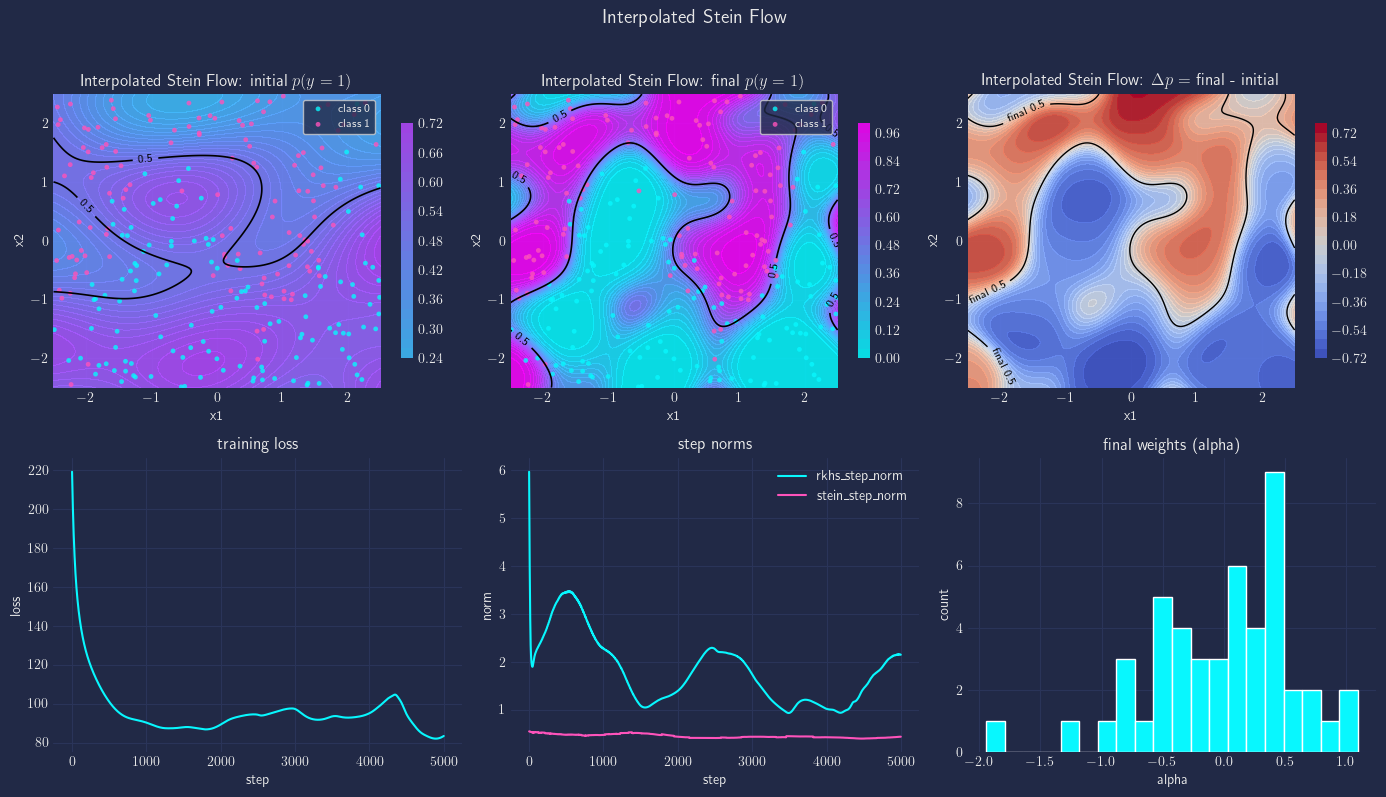

In [7]:
plot_isf_results(
    predictor=predictor,
    data=data,
    Q0=Q0,
    Qhat=Qhat,
    metrics=metrics,
    grid_lim=2.5,
    grid_n=200,
    title_prefix="Interpolated Stein Flow"
)


# tests

In [5]:
import jax, jax.numpy as jnp

# --- Classification ---

def make_spiral_classification(n_per_class=600, noise=0.12, turns=3.0, flip_prob=0.0, key=jax.random.PRNGKey(0)):
    k1, k2, k3, kf = jax.random.split(key, 4)
    # sample angles independently for each class (no pairing)
    t1 = jax.random.uniform(k1, (n_per_class,), minval=0., maxval=turns * 2*jnp.pi)
    t2 = jax.random.uniform(k2, (n_per_class,), minval=0., maxval=turns * 2*jnp.pi)
    r1 = 0.2 + 0.8 * t1 / (turns * 2*jnp.pi)
    r2 = 0.2 + 0.8 * t2 / (turns * 2*jnp.pi)
    X1 = jnp.stack([r1 * jnp.cos(t1), r1 * jnp.sin(t1)], axis=1)
    X2 = jnp.stack([r2 * jnp.cos(t2 + jnp.pi), r2 * jnp.sin(t2 + jnp.pi)], axis=1)
    X = jnp.concatenate([X1, X2], axis=0)
    y = jnp.concatenate([jnp.zeros((n_per_class,)), jnp.ones((n_per_class,))], axis=0)
    X = X + noise * jax.random.normal(k3, X.shape)
    # optional label flips to enforce Bayes error
    if flip_prob > 0:
        flip = jax.random.bernoulli(kf, p=flip_prob, shape=y.shape)
        y = jnp.where(flip, 1.0 - y, y)
    perm = jax.random.permutation(k3, X.shape[0])
    return {"x": X[perm], "y": y[perm].astype(jnp.float32)}


def make_checkerboard_classification(n=2048, cells=4, key=jax.random.PRNGKey(1)):
    k1, k2 = jax.random.split(key)
    X = jax.random.uniform(k1, (n, 2), minval=-3., maxval=3.)
    # non-axis-aligned checkerboard (rotate)
    theta = 0.6
    R = jnp.array([[jnp.cos(theta), -jnp.sin(theta)],[jnp.sin(theta), jnp.cos(theta)]])
    Z = X @ R.T
    cell = (Z + 3.) / (6. / cells)
    y = ((jnp.floor(cell[:,0]) + jnp.floor(cell[:,1])) % 2).astype(jnp.float32)
    y = jnp.where(jax.random.uniform(k2, (n,)) < 0.05, 1. - y, y)  # a bit of label noise
    return {"x": X, "y": y}

# --- Regression (2D, nonstationary, heteroscedastic) ---

def make_bumpy_regression_2d(n=2048, key=jax.random.PRNGKey(2)):
    kx, kn1, kn2 = jax.random.split(key, 3)
    X = jax.random.uniform(kx, (n, 2), minval=-3., maxval=3.)
    x1, x2 = X[:,0], X[:,1]
    f = (jnp.sin(2.2*x1) + 0.6*jnp.cos(1.7*x2)
         + 0.8*jnp.exp(-0.7*((x1-1.2)**2 + (x2+0.8)**2))
         - 0.6*jnp.exp(-3.5*((x1+1.0)**2 + (x2-1.5)**2))
         + 0.25*jnp.sign(x1 - 0.6*x2))  # a small discontinuity
    # heteroscedastic noise
    sigma = 0.05 + 0.25 * jax.nn.sigmoid(1.2*(x1 + 0.5*x2))
    y = f + sigma * jax.random.normal(kn1, (n,))
    return {"x": X, "y": y}, f  # return noiseless f for diagnostics

# --- Add nuisance dimensions (uninformative features) ---

def add_nuisance_dims(data, k_extra=8, scale=1.0, key=jax.random.PRNGKey(3)):
    X = data["x"]; n = X.shape[0]
    Z = scale * jax.random.normal(key, (n, k_extra))
    Xnz = jnp.concatenate([X, Z], axis=1)
    return {"x": Xnz, "y": data["y"]}, k_extra


def train_test_split(data, frac=0.7, key=jax.random.PRNGKey(0)):
    n = data["x"].shape[0]
    idx = jax.random.permutation(key, n)
    n_tr = int(frac * n)
    tr, te = idx[:n_tr], idx[n_tr:]
    dtr = {"x": data["x"][tr], "y": data["y"][tr]}
    dte = {"x": data["x"][te], "y": data["y"][te]}
    return dtr, dte

def add_nuisance_dims(data, k_extra=10, scale=1.0, key=jax.random.PRNGKey(99)):
    X = data["x"]; n = X.shape[0]
    Z = scale * jax.random.normal(key, (n, k_extra))
    return {"x": jnp.concatenate([X, Z], axis=1), "y": data["y"]}


In [22]:
import functools
import jax
import jax.numpy as jnp
from jax import tree_util as jtu  

# ----- MLP params -----
def glorot(k, fan_in, fan_out):
    limit = jnp.sqrt(6.0 / (fan_in + fan_out))
    return jax.random.uniform(k, (fan_in, fan_out), minval=-limit, maxval=limit)

def init_mlp_params(sizes, key):
    """sizes: [in, h1, h2, ..., out]"""
    keys = jax.random.split(key, len(sizes)-1)
    params = []
    for k, (fin, fout) in zip(keys, zip(sizes[:-1], sizes[1:])):
        W = glorot(k, fin, fout)
        b = jnp.zeros((fout,))
        params.append((W, b))
    return params

def mlp_forward(params, x, activation=jax.nn.gelu):
    h = x
    for (W, b) in params[:-1]:
        h = activation(h @ W + b)
    W, b = params[-1]
    return h @ W + b  # raw output (logits for cls, value for reg)

# ----- Adam -----
# ----- Adam -----
@jax.jit  # static_argnames optional; leaving default is fine
def adam_step(params, grads, opt_state, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
    t, m, v = opt_state
    t = t + 1
    m = jtu.tree_map(lambda m_, g_: beta1 * m_ + (1 - beta1) * g_, m, grads)
    v = jtu.tree_map(lambda v_, g_: beta2 * v_ + (1 - beta2) * (g_ * g_), v, grads)
    mhat = jtu.tree_map(lambda m_: m_ / (1 - beta1 ** t), m)
    vhat = jtu.tree_map(lambda v_: v_ / (1 - beta2 ** t), v)
    new_params = jtu.tree_map(lambda p, mh, vh: p - lr * mh / (jnp.sqrt(vh) + eps),
                              params, mhat, vhat)
    return new_params, (t, m, v)

def adam_init(params):
    zeros_like = jtu.tree_map(jnp.zeros_like, params)
    return (jnp.array(0, dtype=jnp.int32), zeros_like, zeros_like)


# ----- Losses -----
def mse_loss(params, X, y):
    pred = mlp_forward(params, X).squeeze(-1)
    r = pred - y
    return jnp.mean(r*r)

def logistic_loss(params, X, y):
    logits = mlp_forward(params, X).squeeze(-1)
    # numerically stable: softplus - y*logits
    return jnp.mean(jnp.logaddexp(0.0, logits) - y*logits)

# ----- Train loops -----
def train_mlp_regression(X, y, hidden=(128,128), epochs=3000, lr=1e-3, l2=1e-5, key=jax.random.PRNGKey(0)):
    sizes = [X.shape[1], *hidden, 1]
    params = init_mlp_params(sizes, key)
    opt = adam_init(params)

    @jax.jit
    def step(params, opt, X, y):
        def loss_fn(p):
            val = mse_loss(p, X, y)
            l2pen = sum(jnp.sum(W*W) for (W, b) in p)
            return val + l2 * l2pen
        val, grads = jax.value_and_grad(loss_fn)(params)
        params2, opt2 = adam_step(params, grads, opt, lr=lr)
        return params2, opt2, val

    hist = []
    for _ in range(epochs):
        params, opt, val = step(params, opt, X, y)
        hist.append(val)
    return params, jnp.stack(hist)

def train_mlp_classification(X, y, hidden=(128,128), epochs=3000, lr=1e-3, l2=1e-5, key=jax.random.PRNGKey(1)):
    sizes = [X.shape[1], *hidden, 1]
    params = init_mlp_params(sizes, key)
    opt = adam_init(params)

    @jax.jit
    def step(params, opt, X, y):
        def loss_fn(p):
            val = logistic_loss(p, X, y)
            l2pen = sum(jnp.sum(W*W) for (W, b) in p)
            return val + l2 * l2pen
        val, grads = jax.value_and_grad(loss_fn)(params)
        params2, opt2 = adam_step(params, grads, opt, lr=lr)
        return params2, opt2, val

    hist = []
    for _ in range(epochs):
        params, opt, val = step(params, opt, X, y)
        hist.append(val)
    return params, jnp.stack(hist)

def predict_mlp(params, X, task="reg"):
    out = mlp_forward(params, X).squeeze(-1)
    if task == "cls":
        return out  # logits
    return out      # values


In [7]:
# 1) data
key = jax.random.PRNGKey(42)
# data2d = make_spiral_classification(n_per_class=600, noise=0.12, turns=3.0, flip_prob=0.05, key=key)
data2d = make_checkerboard_classification(n=1200,cells=4, key=key)

train2d, test2d = train_test_split(data2d, frac=0.7, key=jax.random.PRNGKey(7))
train_hd = add_nuisance_dims(train2d, k_extra=1, key=jax.random.PRNGKey(11))
test_hd  = add_nuisance_dims(test2d,  k_extra=1, key=jax.random.PRNGKey(12))

# 2) ISF setup (train on high-D)
N, d = train_hd["x"].shape
Q0 = init_fourier_particles(n_particles=100, d=d, key=jax.random.PRNGKey(0), w_scale=1.0, alpha_scale=0.05)
prior = NormalDiag(sd=2.0)
predictor = FourierPredictor(prior_plus=prior, prior_minus=prior, data=train_hd)
loss = ISFDeterministicRiskLoss(loss_and_grad=logistic_loss_and_grad)
kparams = KernelParams(lengthscale=jnp.asarray(1.), amplitude=jnp.asarray(1.0))
kernel = RBFKernel()

# 3) Train ISF
Qhat, metrics = isf(
    model=predictor, loss=loss, kernel=kernel, kparams=kparams,
    eps_theta=1e-3, eps_alpha=1e-3, lambda_skl=1., Q0=Q0,
    steps=5000, return_metrics=True
)

# 4) Test accuracy (high-D)
predictor_test = FourierPredictor(prior_plus=prior, prior_minus=prior, data=test_hd)
logits_isf_te = predictor_test.predict(Qhat)
acc_isf_test = float(jnp.mean((jax.nn.sigmoid(logits_isf_te) >= 0.5) == test_hd["y"]))
print("ISF test acc:", acc_isf_test)

# 5) MLP baseline (train on high-D, evaluate on high-D test)
mlp_params, mlp_hist = train_mlp_classification(train_hd["x"], train_hd["y"],
                                                hidden=(32,32), epochs=3000, lr=2e-3, l2=1e-4)
logits_mlp_te = predict_mlp(mlp_params, test_hd["x"], task="cls")
acc_mlp_test = float(jnp.mean((jax.nn.sigmoid(logits_mlp_te) >= 0.5) == test_hd["y"]))
print("MLP test acc:", acc_mlp_test)


ISF test acc: 0.6861111521720886


NameError: name 'train_mlp_classification' is not defined

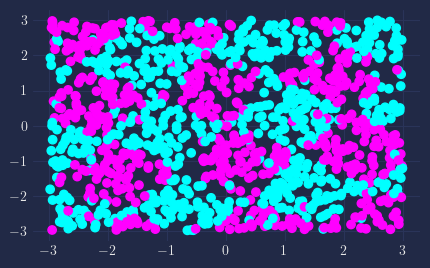

In [38]:
plt.scatter(data2d['x'][:,0], data2d['x'][:,1], c=data2d['y'])

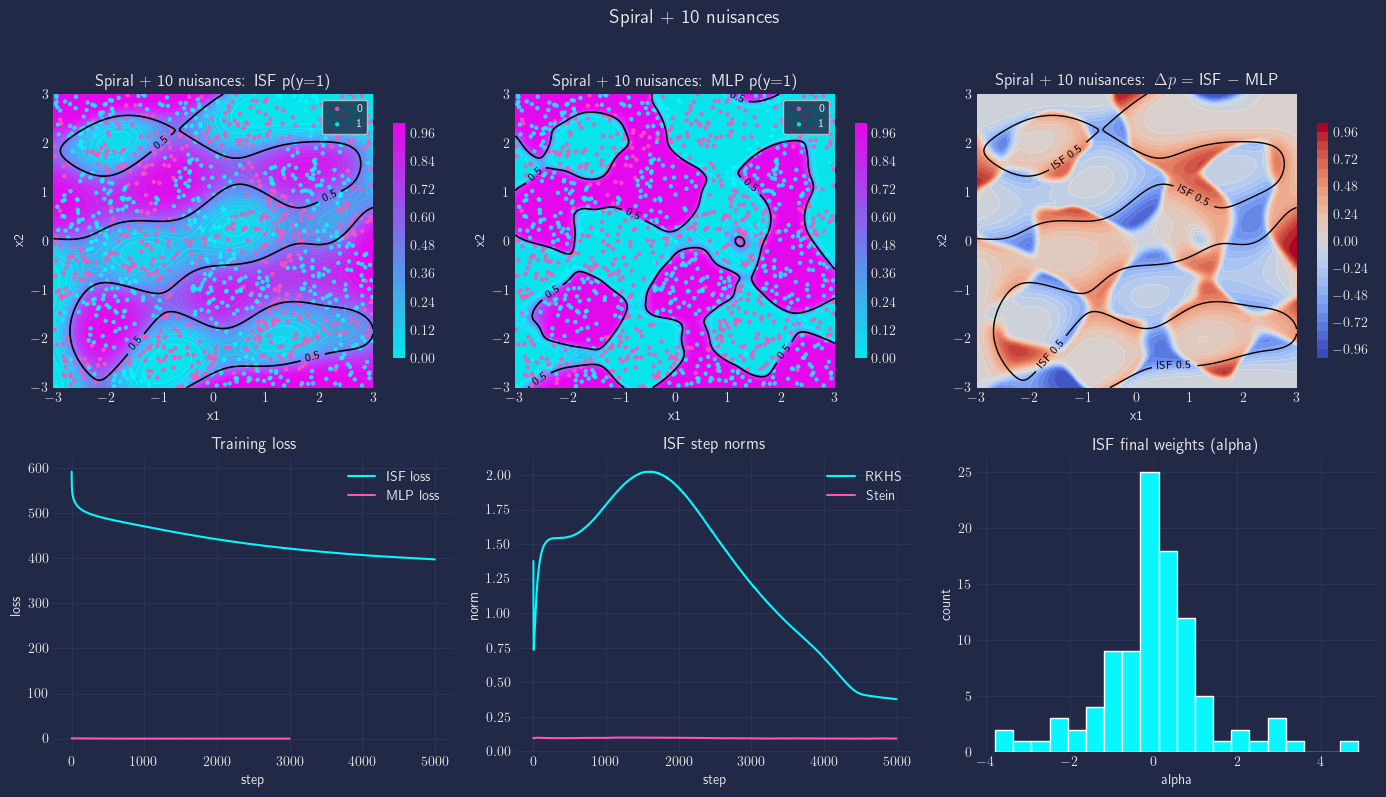

In [ ]:
plot_isf_vs_mlp_onefig(
    predictor=predictor,      
    Qhat=Qhat,                
    mlp_params=mlp_params,    
    data2d=data2d,            
    grid_lim=3.0,
    grid_n=250,
    metrics=metrics,          
    mlp_hist=mlp_hist,       
    title_prefix="Spiral + 10 nuisances"
)


In [16]:
import numpy as np
import matplotlib.pyplot as plt

def plot_isf_vs_mlp_onefig(
    predictor,          # your FourierPredictor trained on data_hd
    Qhat,               # SignedMixtureLike (final ISF particles + alpha)
    mlp_params,         # trained MLP params
    data2d,             # the original 2D dataset dict (for scatter)
    grid_lim=3.0,
    grid_n=250,
    metrics=None,       # ISF metrics dict (optional; for loss/step-norms)
    mlp_hist=None,      # (epochs,) MLP training loss (optional)
    title_prefix="ISF vs MLP"
):
    # ----- helpers -----
    def _to_np(x): return np.asarray(x)
    def _grid_2d(lim, n):
        xs = np.linspace(-lim, lim, n)
        ys = np.linspace(-lim, lim, n)
        XX, YY = np.meshgrid(xs, ys)
        XY = np.stack([XX.ravel(), YY.ravel()], axis=1)  # (n*n, 2)
        return XX, YY, XY

    # Lift 2D grid to full feature dim by zero-padding nuisance dims
    d_full = int(np.asarray(predictor.data[predictor.x_key]).shape[1])
    def _lift_to_full(X2):
        if d_full <= 2:
            return X2
        pad = np.zeros((X2.shape[0], d_full - 2), dtype=X2.dtype)
        return np.concatenate([X2, pad], axis=1)

    # predictor: logits -> probs
    def _predict_isf_probs_on_grid(X2):
        X_full = _lift_to_full(X2)
        logits = _to_np(predictor.predict_on_x(Qhat, X_full))    # (M,)
        return 1.0 / (1.0 + np.exp(-logits))

    # MLP: logits -> probs
    def _predict_mlp_probs_on_grid(X2):
        X_full = _lift_to_full(X2)
        logits = _to_np(predict_mlp(mlp_params, jnp.asarray(X_full), task="cls"))  # (M,)
        return 1.0 / (1.0 + np.exp(-logits))

    # ----- build grid and surfaces -----
    XX, YY, XY = _grid_2d(grid_lim, grid_n)
    P_isf = _predict_isf_probs_on_grid(XY).reshape(XX.shape)
    P_mlp = _predict_mlp_probs_on_grid(XY).reshape(XX.shape)
    dP = P_isf - P_mlp

    X = _to_np(data2d["x"])
    y = _to_np(data2d["y"]).astype(int)

    # ----- layout -----
    fig, axs = plt.subplots(2, 3, figsize=(14, 8))
    ax_isf, ax_mlp, ax_diff = axs[0]
    ax_loss, ax_norms, ax_hist = axs[1]

    # Common surface plotter
    def _plot_surface(ax, Z, ttl, draw_points=True, vmin=0.0, vmax=1.0, levels=25, show_cb=True):
        im = ax.contourf(XX, YY, Z, levels=levels, vmin=vmin, vmax=vmax, alpha=0.9)
        cs = ax.contour(XX, YY, Z, levels=[0.5], colors="k", linewidths=1.2)
        ax.clabel(cs, inline=True, fontsize=8, fmt="0.5")
        if draw_points:
            ax.scatter(X[y==0,0], X[y==0,1], s=10, c="C1", label="0", alpha=0.85, edgecolors="none")
            ax.scatter(X[y==1,0], X[y==1,1], s=10, c="C0", label="1", alpha=0.85, edgecolors="none")
            ax.legend(loc="upper right", frameon=True, fontsize=8)
        ax.set_title(ttl)
        ax.set_xlabel("x1"); ax.set_ylabel("x2")
        ax.set_xlim(-grid_lim, grid_lim); ax.set_ylim(-grid_lim, grid_lim)
        if show_cb: fig.colorbar(im, ax=ax, shrink=0.8)

    # Top row: ISF, MLP, Δ
    _plot_surface(ax_isf, P_isf, f"{title_prefix}: ISF p(y=1)")
    _plot_surface(ax_mlp, P_mlp, f"{title_prefix}: MLP p(y=1)")
    vmax = np.max(np.abs(dP))
    imd = ax_diff.contourf(XX, YY, dP, levels=25, vmin=-vmax, vmax=vmax, cmap="coolwarm", alpha=0.95)
    csd = ax_diff.contour(XX, YY, P_isf, levels=[0.5], colors="k", linewidths=1.0)
    ax_diff.clabel(csd, inline=True, fontsize=8, fmt="ISF 0.5")
    ax_diff.set_title(f"{title_prefix}: $\Delta p$ = ISF − MLP")
    ax_diff.set_xlabel("x1"); ax_diff.set_ylabel("x2")
    ax_diff.set_xlim(-grid_lim, grid_lim); ax_diff.set_ylim(-grid_lim, grid_lim)
    fig.colorbar(imd, ax=ax_diff, shrink=0.8)

    # Bottom-left: training losses (if available)
    got_isf_loss = metrics is not None and "loss" in metrics
    got_mlp_loss = mlp_hist is not None
    if got_isf_loss or got_mlp_loss:
        if got_isf_loss:
            ax_loss.plot(_to_np(metrics["loss"]), label="ISF loss", lw=1.5)
        if got_mlp_loss:
            ax_loss.plot(_to_np(mlp_hist), label="MLP loss", lw=1.5)
        ax_loss.set_title("Training loss")
        ax_loss.set_xlabel("step"); ax_loss.set_ylabel("loss")
        ax_loss.legend()
    else:
        ax_loss.axis("off"); ax_loss.set_title("Training loss (unavailable)")

    # Bottom-middle: ISF step norms (if available)
    has_r = metrics is not None and "rkhs_step_norm" in metrics
    has_s = metrics is not None and "stein_step_norm" in metrics
    if has_r or has_s:
        if has_r: ax_norms.plot(_to_np(metrics["rkhs_step_norm"]), label="RKHS", lw=1.5)
        if has_s: ax_norms.plot(_to_np(metrics["stein_step_norm"]), label="Stein", lw=1.5)
        ax_norms.set_title("ISF step norms")
        ax_norms.set_xlabel("step"); ax_norms.set_ylabel("norm"); ax_norms.legend()
    else:
        ax_norms.axis("off"); ax_norms.set_title("ISF step norms (unavailable)")

    # Bottom-right: ISF final alpha histogram (if available)
    if hasattr(Qhat, "alpha"):
        al = _to_np(Qhat.alpha)
        ax_hist.hist(al, bins=20, edgecolor="white")
        ax_hist.set_title("ISF final weights (alpha)")
        ax_hist.set_xlabel("alpha"); ax_hist.set_ylabel("count")
    else:
        ax_hist.axis("off"); ax_hist.set_title("ISF weights (unavailable)")

    fig.suptitle(title_prefix, y=0.99, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


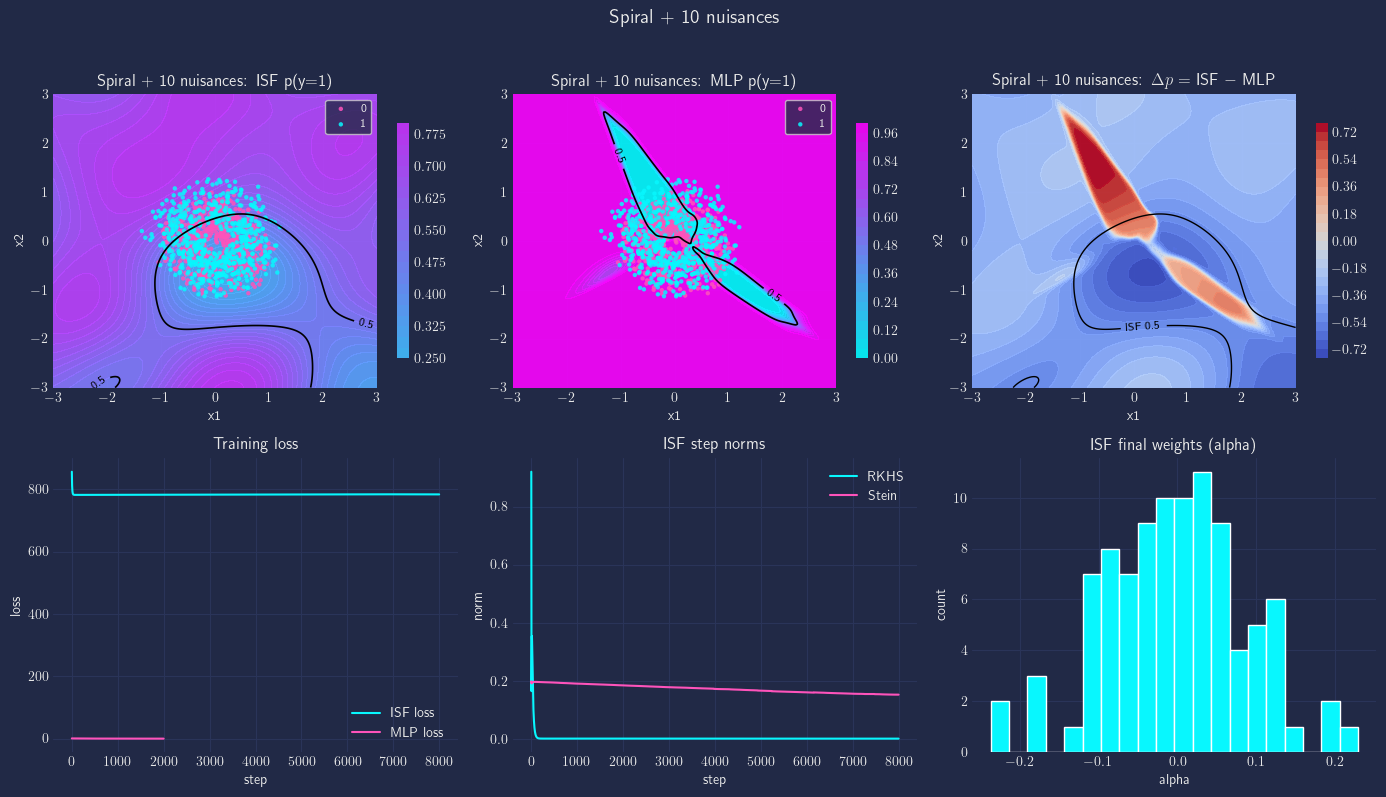

In [17]:
# After you've trained ISF and MLP and computed metrics / mlp_hist:
plot_isf_vs_mlp_onefig(
    predictor=predictor,       # the high-D predictor on data_hd
    Qhat=Qhat,                 # ISF result
    mlp_params=mlp_params,     # trained MLP
    data2d=data2d,             # original 2D dataset for scatter
    grid_lim=3.0,
    grid_n=250,
    metrics=metrics,           # ISF metrics dict (optional)
    mlp_hist=mlp_hist,         # MLP training loss (optional)
    title_prefix="Spiral + 10 nuisances"
)


## Audio Denoising

In [2]:
from vgd.audio import *

In [ ]:
import jax, jax.numpy as jnp
import numpy as np


def hann_window(N: int) -> jnp.ndarray:
    n = jnp.arange(N)
    return 0.5 - 0.5 * jnp.cos(2*jnp.pi*n/(N-1))

def frame_signal(y: jnp.ndarray, frame_len: int, hop: int, pad_end: bool = True):
    """
    Return frames with hop spacing. If pad_end=True, zero-pad the tail so that
    the last frame is complete. Returns (frames, N_orig).
    """
    N = int(y.shape[0])
    if N <= frame_len:
        pad = frame_len - N if pad_end else 0
        y_pad = jnp.pad(y, (0, pad))
        return y_pad[None, :], N

    if pad_end:
        # ceil((N - frame_len)/hop) + 1 frames
        n_steps = (N - frame_len + hop - 1) // hop + 1
        total = hop * (n_steps - 1) + frame_len
        pad = max(0, total - N)
    else:
        n_steps = (N - frame_len) // hop + 1
        pad = 0

    y_pad = jnp.pad(y, (0, pad))
    idx = jnp.arange(frame_len)[None, :] + hop * jnp.arange(n_steps)[:, None]
    frames = y_pad[idx]  # (T, L)
    return frames, N  # keep original N for cropping later

def overlap_add(frames: jnp.ndarray, hop: int, window: jnp.ndarray, N_trim: int | None = None):
    """
    Overlap–add with window reweighting. If N_trim is provided, crop to that length.
    Assumes a COLA-compliant hop/window (e.g., Hann with hop=L/2).
    """
    T, L = frames.shape
    total = hop * (T - 1) + L
    y = jnp.zeros((total,))
    wsum = jnp.zeros((total,))
    for t in range(T):
        start = t * hop
        seg = frames[t] * window
        y = y.at[start:start+L].add(seg)
        wsum = wsum.at[start:start+L].add(window * window)

    if N_trim is not None:
        y = y[:N_trim]
        wsum = wsum[:N_trim]

    wsum = jnp.where(wsum > 1e-12, wsum, 1.0)
    return y / wsum

def snr_db(y_clean: np.ndarray, y_est: np.ndarray) -> float:
    num = np.sum(y_clean**2) + 1e-12
    den = np.sum((y_clean - y_est)**2) + 1e-12
    return float(10*np.log10(num/den))

def play_audio(y: np.ndarray, sr: int = 16000):
    try:
        from IPython.display import Audio, display
        display(Audio(y, rate=sr))
    except Exception as e:
        print("IPython Audio not available:", e)

def save_wav(path: str, y: np.ndarray, sr: int = 16000):
    import scipy.io.wavfile as wav
    y16 = np.clip(y, -1.0, 1.0)
    wav.write(path, sr, (y16*32767).astype(np.int16))




def isf_denoise_audio(
    y_noisy: np.ndarray,
    sr: int = 16000,
    frame_len: int = 1024,
    hop: int = 512,
    n_particles: int = 64,
    steps: int = 400,
    eps_theta: float = 5e-3,
    eps_alpha: float = 5e-4,
    lambda_skl: float = 0.5,
    w_scale: float = 2.0,          # init ω std (rad/s); tune with bandwidth
    alpha_scale: float = 0.05,
    kernel=None,
    kparams=None,
) -> dict:
    """
    Returns dict with 'denoised', 'frames_clean', 'frames_pred', 'Q_last', etc.
    Assumes you have:
      - SignedMixtureLike, FourierPredictor, ISFLoss, isf()
      - RBFKernel() and KernelParams(lengthscale, amplitude)
    """
    y_noisy = np.asarray(y_noisy).astype(np.float32)
    y = jnp.asarray(y_noisy)

    win = hann_window(frame_len)
    frames, N_orig = frame_signal(y, frame_len, hop, pad_end=True)  # (T, L), N
    T, L = frames.shape

    # time axis (seconds) for one frame
    t = (2 * jnp.pi / L) * jnp.arange(L)          # shape (L,)
    X_frame = t[:, None]                           # (L,1)


    # priors for + and - (same here)
    prior = NormalDiag(sd=1.0)

    # init particles for d=1  → θ=(ω, b) ∈ R^2
    def init_fourier_particles_1d(n_particles, key):
        k1,k2,k3 = jax.random.split(key, 3)
        # ω in radians; use a broad Gaussian up to ~Nyquist (π rad/sample ≈ sr/2 Hz)
        omega = jax.random.normal(k1, (n_particles, 1)) * w_scale
        b = jax.random.uniform(k2, (n_particles, 1), minval=0., maxval=2*jnp.pi)
        particles = jnp.concatenate([omega, b], axis=1)  # (n, 2)
        alpha = jax.random.normal(k3, (n_particles,)) * alpha_scale
        return SignedMixtureLike(particles=particles, alpha=alpha)

    # predictor & loss
    loss = ISFDeterministicRiskLoss(loss_and_grad=logistic_loss_and_grad)  # for denoising use **squared** loss
    loss = ISFDeterministicRiskLoss(loss_and_grad=squared_loss_and_grad)

    # kernel defaults if not provided
    if kernel is None:
        kernel = RBFKernel()
    if kparams is None:
        kparams = KernelParams(lengthscale=jnp.asarray(1.0), amplitude=jnp.asarray(1.0))

    frames_pred = []
    Q_last = None
    key = jax.random.PRNGKey(0)

    for t_idx in range(T):
        key, kq = jax.random.split(key)
        y_frame = frames[t_idx] * win  # window in and fit what you synthesize
        data = {"x": X_frame, "y": y_frame}

        Q0 = init_fourier_particles_1d(n_particles, kq) if Q_last is None else Q_last

        predictor = FourierPredictor(
            prior_plus=prior, prior_minus=prior, data=data, x_key="x", y_key="y"
        )

        Qhat, _ = isf(
            model=predictor, loss=loss,
            kernel=kernel, kparams=kparams,
            eps_theta=eps_theta, eps_alpha=eps_alpha,
            lambda_skl=lambda_skl,
            Q0=Q0, steps=steps, return_metrics=False
        )

        # predict denoised frame (logits==value here because squared loss)
        yhat = predictor.predict(Qhat)  # (L,)
        frames_pred.append(yhat)

        # warm-start next frame
        Q_last = Qhat

    frames_pred = jnp.stack(frames_pred, axis=0)  # (T, L)
    y_denoised = overlap_add(frames_pred, hop=hop, window=win, N_trim=int(N_orig))

    return {
        "denoised": np.asarray(y_denoised),
        "frames_pred": np.asarray(frames_pred),
        "Q_last": Q_last,
    }


In [ ]:
import jax, jax.numpy as jnp
import numpy as np


def hann_window(N: int) -> jnp.ndarray:
    n = jnp.arange(N)
    return 0.5 - 0.5 * jnp.cos(2*jnp.pi*n/(N-1))

def frame_signal(y: jnp.ndarray, frame_len: int, hop: int, pad_end: bool = True):
    """
    Return frames with hop spacing. If pad_end=True, zero-pad the tail so that
    the last frame is complete. Returns (frames, N_orig).
    """
    N = int(y.shape[0])
    if N <= frame_len:
        pad = frame_len - N if pad_end else 0
        y_pad = jnp.pad(y, (0, pad))
        return y_pad[None, :], N

    if pad_end:
        # ceil((N - frame_len)/hop) + 1 frames
        n_steps = (N - frame_len + hop - 1) // hop + 1
        total = hop * (n_steps - 1) + frame_len
        pad = max(0, total - N)
    else:
        n_steps = (N - frame_len) // hop + 1
        pad = 0

    y_pad = jnp.pad(y, (0, pad))
    idx = jnp.arange(frame_len)[None, :] + hop * jnp.arange(n_steps)[:, None]
    frames = y_pad[idx]  # (T, L)
    return frames, N  # keep original N for cropping later

def overlap_add(frames: jnp.ndarray, hop: int, window: jnp.ndarray, N_trim: int | None = None):
    """
    Overlap–add with window reweighting. If N_trim is provided, crop to that length.
    Assumes a COLA-compliant hop/window (e.g., Hann with hop=L/2).
    """
    T, L = frames.shape
    total = hop * (T - 1) + L
    y = jnp.zeros((total,))
    wsum = jnp.zeros((total,))
    for t in range(T):
        start = t * hop
        seg = frames[t] * window
        y = y.at[start:start+L].add(seg)
        wsum = wsum.at[start:start+L].add(window)

    if N_trim is not None:
        y = y[:N_trim]
        wsum = wsum[:N_trim]

    wsum = jnp.where(wsum > 1e-12, wsum, 1.0)
    return y / wsum

def snr_db(y_clean: np.ndarray, y_est: np.ndarray) -> float:
    num = np.sum(y_clean**2) + 1e-12
    den = np.sum((y_clean - y_est)**2) + 1e-12
    return float(10*np.log10(num/den))

def play_audio(y: np.ndarray, sr: int = 16000):
    try:
        from IPython.display import Audio, display
        display(Audio(y, rate=sr))
    except Exception as e:
        print("IPython Audio not available:", e)

def save_wav(path: str, y: np.ndarray, sr: int = 16000):
    import scipy.io.wavfile as wav
    y16 = np.clip(y, -1.0, 1.0)
    wav.write(path, sr, (y16*32767).astype(np.int16))




# --- make a synthetic 2-second signal ---
sr = 16000
t = np.arange(sr*2) / sr
# sparse, time-varying spectrum (two tones + one slowly sweeping chirp)
clean = (0.6*np.sin(2*np.pi*220*t)
         + 0.3*np.sin(2*np.pi*440*t + 0.5)
         + 0.2*np.sin(2*np.pi*(200 + 100*t)*t))
# add white noise at ~0 dB SNR
rng = np.random.default_rng(0)
noise = 0.8 * rng.standard_normal(clean.shape)
noisy = clean + noise

print("Noisy SNR:", snr_db(clean, noisy))

# --- run ISF denoiser ---
res = isf_denoise_audio(
    y_noisy=noisy, sr=sr,
    frame_len=1024, hop=512,
    n_particles=32, steps=32,
    eps_theta=1e-4, eps_alpha=1e-5,
    lambda_skl=0.5,
    w_scale=3.0, alpha_scale=0.05,
    kernel=RBFKernel(),
    kparams=KernelParams(lengthscale=jnp.asarray(1.0), amplitude=jnp.asarray(1.0)),
)
den = res["denoised"]
print("Denoised SNR:", snr_db(clean, den))

# --- listen (in a notebook) ---
play_audio(noisy, sr)
play_audio(den,   sr)

# --- optionally save to WAVs ---
# save_wav("noisy.wav", noisy, sr)
# save_wav("denoised_isf.wav", den, sr)


Noisy SNR: -4.0557667536279824
Denoised SNR: -0.017249971787482825


In [16]:
den

array([ 0.        , -0.00032849, -0.00034991, ...,  0.00054257,
        0.00053545,  0.00052833])

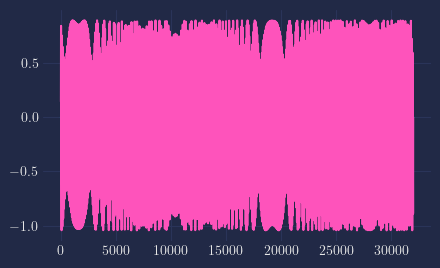

In [20]:
plt.plot(den)
plt.plot(clean)

In [15]:
play_audio(clean, sr)
